In [182]:
import pandas as pd
from canexao import connect_to_mongo
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff


collection_users, collection_tasks = connect_to_mongo()
tabela_users = pd.DataFrame(list(collection_users.find()))
tabela = pd.DataFrame(list(collection_tasks.find()))


Conexão estabelecida com sucesso!


In [183]:
tabela.head()

,_id,task_id,titulo,descricao,prioridade,user_id,mentorado,area_atuacao,mentor_responsavel,data_criacao,data_inicio,status_atual,data_conclusao,feedback_conclusao_mentorado,createdAt,updatedAt,__v
0,6a2b884993a2aac46c8ba14a,1.0,Otimizar Microsserviços - Sprint 8,Atividade focada em otimizar o recurso de micr...,media,6a2b8445cf36b576d237ae6b,Bruno Costa,DevBack-end,Juliana Costa,2026-05-05,2026-05-07,andamento,NaT,NaN,NaT,NaT,NaN
1,6a2b884993a2aac46c8ba14b,2.0,Testar Scripts de Deploy - Sprint 2,Atividade focada em testar o recurso de script...,alta,6a2b8468cf36b576d237ae6c,Felipe Andrade,QA,Juliana Costa,2026-03-25,2026-03-27,concluida,2026-04-02,Os testes cobriram os cenários críticos de aut...,NaT,NaT,NaN
2,6a2b884993a2aac46c8ba14c,3.0,Testar Cache em Redis - Sprint 2,Atividade focada em testar o recurso de cache ...,media,6a2b8468cf36b576d237ae6c,Felipe Andrade,QA,Juliana Costa,2026-03-26,2026-03-27,concluida,2026-04-06,Validação executada com sucesso. O fluxo corre...,NaT,NaT,NaN
3,6a2b884993a2aac46c8ba14d,4.0,Testar Componentes React - Sprint 8,Atividade focada em testar o recurso de compon...,media,6a2b8496cf36b576d237ae6d,Diego Martins,QA,Juliana Costa,2026-04-20,2026-04-21,concluida,2026-04-27,Conseguimos manter uma boa cobertura de testes...,NaT,NaT,NaN
4,6a2b884993a2aac46c8ba14e,5.0,Ajustar Exportação de Relatórios - Sprint 3,Atividade focada em ajustar o recurso de expor...,media,6a2b84b4cf36b576d237ae6e,Camila Lopes,Produto,Juliana Costa,2026-03-02,2026-03-05,concluida,2026-03-19,Os ajustes visuais foram concluídos no prazo. ...,NaT,NaT,NaN


In [184]:
# Mostra o número de linhas, colunas e o tipo de dados de cada coluna
tabela.info()

# Mostra um resumo estatístico das colunas numéricas
tabela.describe()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   _id                           77 non-null     object        
 1   task_id                       76 non-null     float64       
 2   titulo                        77 non-null     str           
 3   descricao                     77 non-null     str           
 4   prioridade                    77 non-null     str           
 5   user_id                       77 non-null     object        
 6   mentorado                     77 non-null     str           
 7   area_atuacao                  76 non-null     str           
 8   mentor_responsavel            77 non-null     str           
 9   data_criacao                  76 non-null     datetime64[us]
 10  data_inicio                   63 non-null     datetime64[us]
 11  status_atual                  77 non-null    

,task_id,data_criacao,data_inicio,data_conclusao,createdAt,updatedAt,__v
count,76.000000,76,63,44,1,1,1.0
mean,38.500000,2026-04-18 14:31:34.736842,2026-04-14 17:54:17.142857,2026-04-12 08:10:54.545454,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
min,1.000000,2026-03-01 00:00:00,2026-03-03 00:00:00,2026-03-09 00:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
25%,19.750000,2026-03-23 18:00:00,2026-03-23 12:00:00,2026-03-27 06:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
50%,38.500000,2026-04-28 00:00:00,2026-04-16 00:00:00,2026-04-05 12:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
75%,57.250000,2026-05-12 00:00:00,2026-05-08 12:00:00,2026-04-29 06:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
max,76.000000,2026-05-27 00:00:00,2026-06-11 00:00:00,2026-06-15 00:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
std,22.083176,NaN,NaN,NaN,NaN,NaN,NaN


In [185]:
# 1. Converter as colunas de data de texto para o formato de data real (datetime)
tabela['data_criacao'] = pd.to_datetime(tabela['data_criacao'], errors='coerce')
tabela['data_inicio'] = pd.to_datetime(tabela['data_inicio'], errors='coerce')
tabela['data_conclusao'] = pd.to_datetime(tabela['data_conclusao'], errors='coerce')

# 2. Criar uma coluna útil: Tempo de Resolução (em dias) entre a criação e a conclusão
tabela['tempo_conclusao_dias'] = (tabela['data_conclusao'] - tabela['data_criacao']).dt.days

# Verificando se as transformações deram certo
tabela[['data_criacao', 'data_inicio', 'data_conclusao', 'tempo_conclusao_dias']].info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   data_criacao          76 non-null     datetime64[us]
 1   data_inicio           63 non-null     datetime64[us]
 2   data_conclusao        44 non-null     datetime64[us]
 3   tempo_conclusao_dias  43 non-null     float64       
dtypes: datetime64[us](3), float64(1)
memory usage: 2.5 KB


In [186]:
tabela['tempo_conclusao_dias'].describe()

count    43.000000
mean     12.697674
std       5.307384
min       4.000000
25%       8.000000
50%      12.000000
75%      17.000000
max      23.000000
Name: tempo_conclusao_dias, dtype: float64

In [187]:
# 1. Média de dias para concluir uma tarefa
media_dias = tabela['tempo_conclusao_dias'].mean()
mediana_dias = tabela['tempo_conclusao_dias'].median()
max_dias = tabela['tempo_conclusao_dias'].max()

print(f"⏱️ Tempo Médio de Conclusão: {media_dias:.1f} dias")
print(f"🎯 Mediana do Tempo (50% das tarefas): {mediana_dias:.1f} dias")
print(f"🚨 Tarefa mais demorada levou: {max_dias:.1f} dias")
print("-" * 50)

# 2. Qual área de atuação demora mais para concluir as tarefas?
print("🐢 Tempo médio de conclusão por ÁREA DE ATUAÇÃO:")
print(tabela.groupby('area_atuacao')['tempo_conclusao_dias'].mean().sort_values(ascending=False))
print("-" * 50)

# 3. Qual nível de prioridade está levando mais tempo?
print("⚠️ Tempo médio de conclusão por PRIORIDADE:")
print(tabela.groupby('prioridade')['tempo_conclusao_dias'].mean().sort_values(ascending=False))

⏱️ Tempo Médio de Conclusão: 12.7 dias
🎯 Mediana do Tempo (50% das tarefas): 12.0 dias
🚨 Tarefa mais demorada levou: 23.0 dias
--------------------------------------------------
🐢 Tempo médio de conclusão por ÁREA DE ATUAÇÃO:
area_atuacao
Data Engineer    15.200000
DevBack-end      13.857143
QA               12.500000
UX/UIDesigner    12.000000
DevMobile        10.800000
Produto          10.666667
DevFront-end     10.571429
Name: tempo_conclusao_dias, dtype: float64
--------------------------------------------------
⚠️ Tempo médio de conclusão por PRIORIDADE:
prioridade
media    13.157895
alta     12.533333
baixa    12.000000
Name: tempo_conclusao_dias, dtype: float64


In [188]:
# 1. Distribuição Geral dos Status (Quantidade e Percentual)
print("📊 DISTRIBUIÇÃO GERAL DOS STATUS:")
status_qtd = tabela['status_atual'].value_counts()
status_pct = tabela['status_atual'].value_counts(normalize=True) * 100

for status in status_qtd.index:
    print(f"• {status}: {status_qtd[status]} tarefas ({status_pct[status]:.1f}%)")
print("-" * 50)

# 2. Quais áreas têm mais tarefas que ainda NÃO foram concluídas?
# Filtrando onde a data de conclusão está vazia (NaN)
print("⏳ TAREFAS PENDENTES (Não concluídas) POR ÁREA DE ATUAÇÃO:")
pendentes_por_area = tabela[tabela['data_conclusao'].isna()]['area_atuacao'].value_counts()
print(pendentes_por_area)
print("-" * 50)

# 3. Cruzamento: Quem está cuidando de quais status?
print("🤝 STATUS DAS TAREFAS POR MENTOR RESPONSÁVEL:")
print(pd.crosstab(tabela['mentor_responsavel'], tabela['status_atual']))

📊 DISTRIBUIÇÃO GERAL DOS STATUS:
• concluida: 44 tarefas (57.1%)
• andamento: 19 tarefas (24.7%)
• pendente: 14 tarefas (18.2%)
--------------------------------------------------
⏳ TAREFAS PENDENTES (Não concluídas) POR ÁREA DE ATUAÇÃO:
area_atuacao
QA               9
Data Engineer    6
DevMobile        5
Produto          4
DevBack-end      3
UX/UIDesigner    3
DevFront-end     3
Name: count, dtype: int64
--------------------------------------------------
🤝 STATUS DAS TAREFAS POR MENTOR RESPONSÁVEL:
status_atual        andamento  concluida  pendente
mentor_responsavel                                
Juliana Costa              19         44        14


C:\Users\lmm4\AppData\Local\Temp\ipykernel_30344\3819263364.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pendentes_por_area.values, y=pendentes_por_area.index, palette="danger_r" if "danger_r" in dir(sns.color_palette) else "Reds_r")


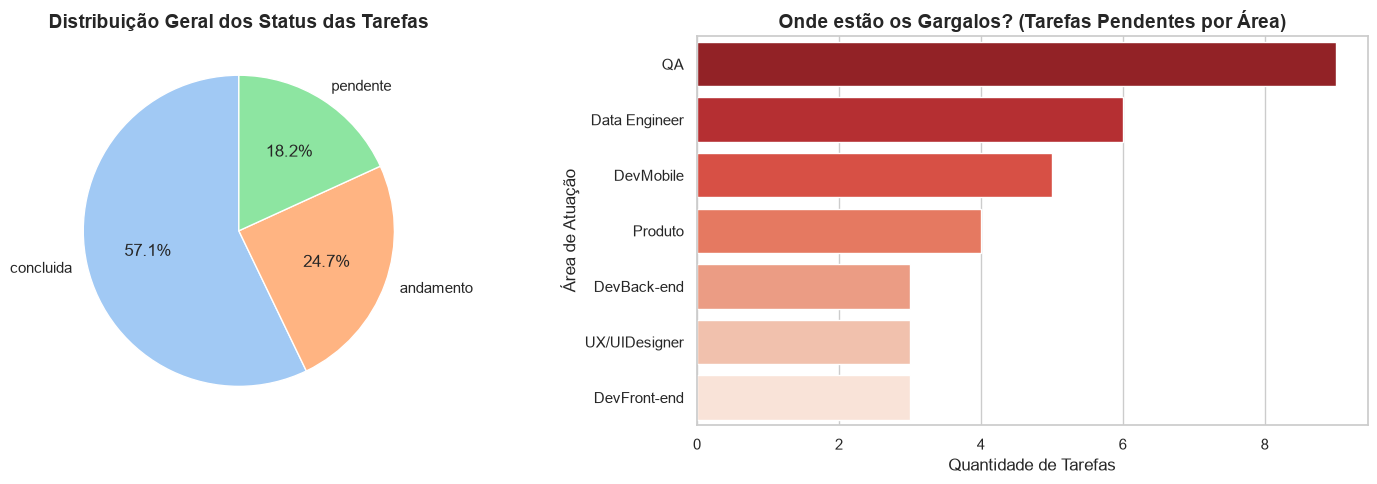

In [189]:


# Configurando o estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Gráfico 1: Distribuição de Status
plt.subplot(1, 2, 1)
status_cores = sns.color_palette("pastel")[0:3]
plt.pie(status_qtd, labels=status_qtd.index, autopct='%1.1f%%', startangle=90, colors=status_cores)
plt.title("Distribuição Geral dos Status das Tarefas", fontsize=14, fontweight='bold')

# Gráfico 2: Tarefas Pendentes por Área
plt.subplot(1, 2, 2)
sns.barplot(x=pendentes_por_area.values, y=pendentes_por_area.index, palette="danger_r" if "danger_r" in dir(sns.color_palette) else "Reds_r")
plt.title("Onde estão os Gargalos? (Tarefas Pendentes por Área)", fontsize=14, fontweight='bold')
plt.xlabel("Quantidade de Tarefas")
plt.ylabel("Área de Atuação")

plt.tight_layout()
plt.show()

In [219]:
databcorte = pd.to_datetime('2026-05-31')


tabela['duracao_em_dias'] = np.nan
tabela['tempo_no_backlog'] = np.nan


task_concluida = tabela['status_atual'] == 'concluida'
tabela.loc[task_concluida, 'duracao_em_dias'] = (tabela.loc[task_concluida, 'data_conclusao'] - tabela.loc[task_concluida, 'data_inicio']).dt.days

task_andamento = tabela['status_atual'] == 'andamento'
tabela.loc[task_andamento, 'duracao_em_dias'] = (databcorte - tabela.loc[task_andamento, 'data_inicio']).dt.days

task_pendente = tabela['status_atual'] == 'pendente'
tabela.loc[task_pendente, 'duracao_em_dias'] = (databcorte - tabela.loc[task_pendente, 'data_criacao']).dt.days


tabela['tempo_no_backlog'] = np.where(
    tabela['status_atual'] == 'pendente',
    (databcorte - tabela['data_criacao']).dt.days,
    (tabela['data_inicio'] - tabela['data_criacao']).dt.days
)

print(tabela[['status_atual', 'duracao_em_dias', 'tempo_no_backlog']].head(10))

  status_atual  duracao_em_dias  tempo_no_backlog
0    andamento             24.0               2.0
1    concluida              6.0               2.0
2    concluida             10.0               1.0
3    concluida              6.0               1.0
4    concluida             14.0               3.0
5    andamento             24.0               2.0
6     pendente             14.0              14.0
7    concluida              9.0               1.0
8    andamento             24.0               2.0
9    concluida             11.0               2.0


# MENTORADA(Filtro)



In [220]:
tabela['mentorado'].value_counts()

mentorado
Ana Ribeiro       16
Bruno Costa       10
Felipe Andrade    10
Eduarda Souza     10
Gabriela Pinto    10
Diego Martins      9
Camila Lopes       7
Henrique Alves     4
Milenna Xavier     1
Name: count, dtype: int64

In [221]:
mentorada = tabela[tabela['mentorado'] == 'Ana Ribeiro'].copy()
mentorada.head(16)

,_id,task_id,titulo,descricao,prioridade,user_id,mentorado,area_atuacao,mentor_responsavel,data_criacao,data_inicio,status_atual,data_conclusao,feedback_conclusao_mentorado,createdAt,updatedAt,__v,tempo_conclusao_dias,duracao_em_dias,tempo_no_backlog
7,6a2b884993a2aac46c8ba151,8.0,Criar Scripts de Deploy - Sprint 2,Atividade focada em criar o recurso de scripts...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-04-20,2026-04-21,concluida,2026-04-30,Atividade finalizada com sucesso. A automação ...,NaT,NaT,NaN,10.0,9.0,1.0
10,6a2b884993a2aac46c8ba154,11.0,Atualizar Pipeline CI/CD - Sprint 1,Atividade focada em atualizar o recurso de pip...,media,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-03-04,2026-03-05,concluida,2026-03-12,Otimizamos o tempo total do fluxo de integraçã...,NaT,NaT,NaN,8.0,7.0,1.0
13,6a2b884993a2aac46c8ba157,14.0,Documentar Tabelas no BD - Sprint 4,Atividade focada em documentar o recurso de ta...,baixa,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-04-15,2026-04-16,concluida,2026-05-01,Dicionário de dados atualizado com sucesso no ...,NaT,NaT,NaN,16.0,15.0,1.0
14,6a2b884993a2aac46c8ba158,15.0,Criar Pipeline CI/CD - Sprint 6,Atividade focada em criar o recurso de pipelin...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-04-21,2026-04-23,concluida,2026-05-10,Pipeline criado do zero para os novos serviços...,NaT,NaT,NaN,19.0,17.0,2.0
17,6a2b884993a2aac46c8ba15b,18.0,Implementar Scripts de Deploy - Sprint 1,Atividade focada em implementar o recurso de s...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-05-12,2026-05-17,andamento,NaT,NaN,NaT,NaT,NaN,NaN,14.0,5.0
21,6a2b884993a2aac46c8ba15f,22.0,Documentar Tabelas no BD - Sprint 6,Atividade focada em documentar o recurso de ta...,baixa,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-03-20,2026-03-22,concluida,2026-04-01,Documentação finalizada englobando os esquemas...,NaT,NaT,NaN,12.0,10.0,2.0
30,6a2b884993a2aac46c8ba168,31.0,Atualizar Scripts de Deploy - Sprint 6,Atividade focada em atualizar o recurso de scr...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-05-08,2026-05-11,concluida,2026-05-31,Adicionamos notificações via Slack e tratament...,NaT,NaT,NaN,23.0,20.0,3.0
31,6a2b884993a2aac46c8ba169,32.0,Ajustar Pipeline CI/CD - Sprint 9,Atividade focada em ajustar o recurso de pipel...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-03-05,2026-03-08,concluida,2026-03-13,Ajustamos os gatilhos para evitar deploys acid...,NaT,NaT,NaN,8.0,5.0,3.0
34,6a2b884993a2aac46c8ba16c,35.0,Implementar Tabelas no BD - Sprint 5,Atividade focada em implementar o recurso de t...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-05-14,NaT,pendente,NaT,NaN,NaT,NaT,NaN,NaN,17.0,17.0
36,6a2b884993a2aac46c8ba16e,37.0,Otimizar Pipeline CI/CD - Sprint 2,Atividade focada em otimizar o recurso de pipe...,media,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-05-10,NaT,pendente,NaT,NaN,NaT,NaT,NaN,NaN,21.0,21.0


In [222]:
mentorada.drop(columns=['descricao', 'mentor_responsavel', 'createdAt','updatedAt','__v', '_id','user_id'], inplace=True, errors='ignore')

In [195]:
mentorada.isnull().sum()

task_id                         0
titulo                          0
prioridade                      0
mentorado                       0
area_atuacao                    0
data_criacao                    0
data_inicio                     3
status_atual                    0
data_conclusao                  6
feedback_conclusao_mentorado    6
tempo_conclusao_dias            6
duracao_em_dias                 0
tempo_no_backlog                0
dtype: int64

In [196]:
mentorada.duplicated().sum()

np.int64(0)

In [212]:
mentorada.head(16)

,task_id,titulo,prioridade,mentorado,area_atuacao,data_criacao,data_inicio,status_atual,data_conclusao,feedback_conclusao_mentorado,tempo_conclusao_dias,duracao_em_dias,tempo_no_backlog,meta_dias
7,8.0,Criar Scripts de Deploy - Sprint 2,alta,Ana Ribeiro,Data Engineer,2026-04-20,2026-04-21,concluida,2026-04-30,Atividade finalizada com sucesso. A automação ...,10.0,9.0,1.0,9.9
10,11.0,Atualizar Pipeline CI/CD - Sprint 1,media,Ana Ribeiro,Data Engineer,2026-03-04,2026-03-05,concluida,2026-03-12,Otimizamos o tempo total do fluxo de integraçã...,8.0,7.0,1.0,11.4
13,14.0,Documentar Tabelas no BD - Sprint 4,baixa,Ana Ribeiro,Data Engineer,2026-04-15,2026-04-16,concluida,2026-05-01,Dicionário de dados atualizado com sucesso no ...,16.0,15.0,1.0,10.2
14,15.0,Criar Pipeline CI/CD - Sprint 6,alta,Ana Ribeiro,Data Engineer,2026-04-21,2026-04-23,concluida,2026-05-10,Pipeline criado do zero para os novos serviços...,19.0,17.0,2.0,9.9
17,18.0,Implementar Scripts de Deploy - Sprint 1,alta,Ana Ribeiro,Data Engineer,2026-05-12,2026-05-17,andamento,NaT,NaN,NaN,14.0,5.0,9.9
21,22.0,Documentar Tabelas no BD - Sprint 6,baixa,Ana Ribeiro,Data Engineer,2026-03-20,2026-03-22,concluida,2026-04-01,Documentação finalizada englobando os esquemas...,12.0,10.0,2.0,10.2
30,31.0,Atualizar Scripts de Deploy - Sprint 6,alta,Ana Ribeiro,Data Engineer,2026-05-08,2026-05-11,concluida,2026-05-31,Adicionamos notificações via Slack e tratament...,23.0,20.0,3.0,9.9
31,32.0,Ajustar Pipeline CI/CD - Sprint 9,alta,Ana Ribeiro,Data Engineer,2026-03-05,2026-03-08,concluida,2026-03-13,Ajustamos os gatilhos para evitar deploys acid...,8.0,5.0,3.0,9.9
34,35.0,Implementar Tabelas no BD - Sprint 5,alta,Ana Ribeiro,Data Engineer,2026-05-14,NaT,pendente,NaT,NaN,NaN,17.0,17.0,9.9
36,37.0,Otimizar Pipeline CI/CD - Sprint 2,media,Ana Ribeiro,Data Engineer,2026-05-10,NaT,pendente,NaT,NaN,NaN,21.0,21.0,11.4


In [198]:
mentorada.info()

<class 'pandas.DataFrame'>
Index: 16 entries, 7 to 71
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   task_id                       16 non-null     float64       
 1   titulo                        16 non-null     str           
 2   prioridade                    16 non-null     str           
 3   mentorado                     16 non-null     str           
 4   area_atuacao                  16 non-null     str           
 5   data_criacao                  16 non-null     datetime64[us]
 6   data_inicio                   13 non-null     datetime64[us]
 7   status_atual                  16 non-null     str           
 8   data_conclusao                10 non-null     datetime64[us]
 9   feedback_conclusao_mentorado  10 non-null     str           
 10  tempo_conclusao_dias          10 non-null     float64       
 11  duracao_em_dias               16 non-null     floa

# EDA -MENTORADA



In [223]:
concluidas_ment = mentorada[mentorada['status_atual'] == 'concluida']
andamento_ment = mentorada[mentorada['status_atual'] == 'andamento']
pendentes_ment = mentorada[mentorada['status_atual'] == 'pendente']

print("\n--- DURAÇÃO EM DIAS (MÉDIAS) ---")
print(f"Média Conclusão: {concluidas_ment['duracao_em_dias'].mean().round(1)} dias")
print(f"Média Em Andamento (dias rodando): {andamento_ment['duracao_em_dias'].mean().round(1)} dias")
print(f"Média Pendente (dias parada): {pendentes_ment['duracao_em_dias'].mean().round(1)} dias")

print("\n--- TEMPO NO BACKLOG (MÉDIAS) ---")
print(f"Tempo no Backlog (Concluídas): {concluidas_ment['tempo_no_backlog'].mean().round(1)} dias")
print(f"Tempo no Backlog (Em Andamento): {andamento_ment['tempo_no_backlog'].mean().round(1)} dias")
print(f"Tempo no Backlog (Pendentes): {pendentes_ment['tempo_no_backlog'].mean().round(1)} dias")


--- DURAÇÃO EM DIAS (MÉDIAS) ---
Média Conclusão: 13.2 dias
Média Em Andamento (dias rodando): 7.0 dias
Média Pendente (dias parada): 14.0 dias

--- TEMPO NO BACKLOG (MÉDIAS) ---
Tempo no Backlog (Concluídas): 2.0 dias
Tempo no Backlog (Em Andamento): 3.3 dias
Tempo no Backlog (Pendentes): 14.0 dias


In [224]:
status_contagem = mentorada['status_atual'].value_counts()
status_percentual = (mentorada['status_atual'].value_counts(normalize=True) * 100).round(1)


df_status = pd.DataFrame({'Quantidade': status_contagem, 'Percentual (%)': status_percentual})
display(df_status)



,Quantidade,Percentual (%)
status_atual,,
concluida,10,62.5
andamento,3,18.8
pendente,3,18.8


In [203]:
media_por_prioridade = mentorada.groupby('prioridade')['duracao_em_dias'].mean().round(1)
print( f'A média de dias por prioridade é: {media_por_prioridade}')

mediana_por_prioridade = mentorada.groupby('prioridade')['duracao_em_dias'].median().round(1)
print(f'A mediana de dias por prioridade é: {mediana_por_prioridade}')

A média de dias por prioridade é: prioridade
alta     11.2
baixa    12.5
media    15.7
Name: duracao_em_dias, dtype: float64
A mediana de dias por prioridade é: prioridade
alta     11.0
baixa    12.5
media    19.0
Name: duracao_em_dias, dtype: float64


In [204]:
mentorada.describe()

,task_id,data_criacao,data_inicio,data_conclusao,tempo_conclusao_dias,duracao_em_dias,tempo_no_backlog
count,16.000000,16,13,10,10.000000,16.000000,16.000000
mean,37.062500,2026-04-19 09:00:00,2026-04-15 07:23:04.615384,2026-04-16 21:36:00,15.200000,12.187500,4.500000
min,8.000000,2026-03-03 00:00:00,2026-03-04 00:00:00,2026-03-12 00:00:00,8.000000,2.000000,1.000000
25%,17.250000,2026-03-21 12:00:00,2026-03-22 00:00:00,2026-03-25 06:00:00,10.500000,6.500000,1.000000
50%,33.500000,2026-04-22 12:00:00,2026-04-21 00:00:00,2026-04-17 12:00:00,15.000000,12.500000,3.000000
75%,54.000000,2026-05-12 12:00:00,2026-05-11 00:00:00,2026-05-07 18:00:00,19.750000,17.500000,4.000000
max,72.000000,2026-05-27 00:00:00,2026-05-29 00:00:00,2026-05-31 00:00:00,23.000000,21.000000,21.000000
std,22.040777,NaN,NaN,NaN,5.652925,6.358393,5.842374


In [225]:
Q1 = mentorada['duracao_em_dias'].quantile(0.25)
Q3 = mentorada['duracao_em_dias'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print(f"\nLimite Superior de dias normais: {limite_superior}")


Limite Superior de dias normais: 34.0


In [227]:
historico = tabela[tabela['status_atual'] == 'concluida']
mediana_geral_por_prioridade = historico.groupby('prioridade')['duracao_em_dias'].median().round(1) 

# mapear pela mediana visando uma avaliação mais realista, já que a média pode ser distorcida por outliers (tarefas que demoraram muito mais do que o normal). A mediana nos dá uma visão mais robusta do tempo típico de conclusão para cada prioridade.
tarefas_n_concluida = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()
tarefas_n_concluida['tempo_limite'] = tarefas_n_concluida['prioridade'].map(mediana_geral_por_prioridade) 

print("\n--- AVALIAÇÃO DE GARGALO FUTURO ---")
display(tarefas_n_concluida[['titulo', 'status_atual', 'prioridade', 'duracao_em_dias', 'tempo_limite']])


--- AVALIAÇÃO DE GARGALO FUTURO ---


,titulo,status_atual,prioridade,duracao_em_dias,tempo_limite
17,Implementar Scripts de Deploy - Sprint 1,andamento,alta,14.0,8.5
34,Implementar Tabelas no BD - Sprint 5,pendente,alta,17.0,8.5
36,Otimizar Pipeline CI/CD - Sprint 2,pendente,media,21.0,11.0
49,Criar Pipeline CI/CD - Sprint 7,andamento,alta,2.0,8.5
56,Otimizar Scripts de Deploy - Sprint 8,pendente,alta,4.0,8.5
66,Atualizar Scripts de Deploy - Sprint 9,andamento,alta,5.0,8.5


#GRAFICOS

##card - valores totais, médias gerais, ou algo muito expecidfico

O total de atividade de Ana é: 16


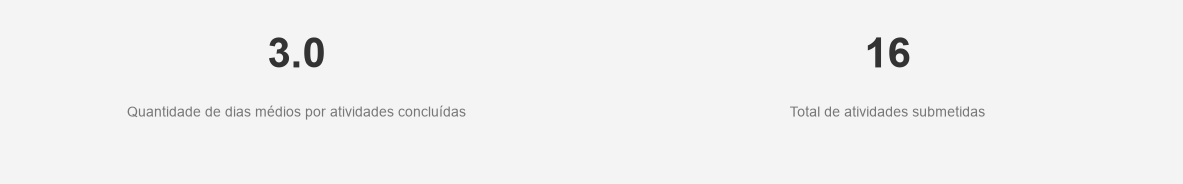

In [239]:
#CARD total de atividade escaladas(sugestao)


totalatividades = mentorada['status_atual'].count()
print(f'O total de atividade de Ana é: {totalatividades}')

mediaconclusao = mentorada['tempo_no_backlog'].median()
fig, axes = plt.subplots(1, 2, figsize=(12, 2)) # 1 row, 2 columns

ax = axes[0]
ax.patch.set_facecolor('#f4f4f4')
fig.patch.set_facecolor('#f4f4f4')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.text(0.5, 0.65, str(mediaconclusao), fontsize=30, fontweight='bold', ha='center', color='#333333', transform=ax.transAxes)
ax.text(0.5, 0.35, 'Quantidade de dias médios por atividades concluídas', fontsize=10, ha='center', color='#777777', transform=ax.transAxes)


# Card 2: Total de Atividades
ax = axes[1]
ax.patch.set_facecolor('#f4f4f4')
fig.patch.set_facecolor('#f4f4f4')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.text(0.5, 0.65, str(totalatividades), fontsize=30, fontweight='bold', ha='center', color='#333333', transform=ax.transAxes)
ax.text(0.5, 0.35, 'Total de atividades submetidas', fontsize=10, ha='center', color='#777777', transform=ax.transAxes)


plt.tight_layout()
plt.show()

tempo médio(em dias) da conclusão é:13.2


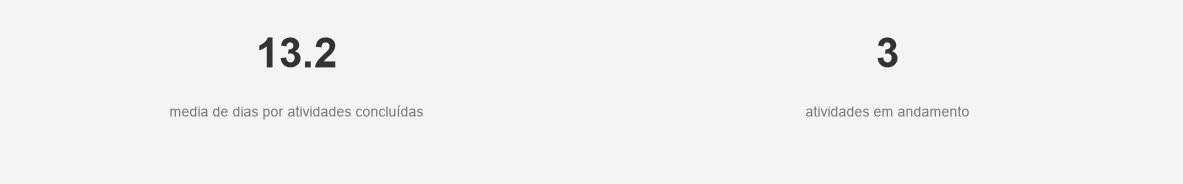

In [237]:
#CARD TEMPO MEDIO POR ENTREGA

mediaconclusao = mentorada[mentorada['status_atual'] == 'concluida']['duracao_em_dias'].mean().round(1)
print(f'tempo médio(em dias) da conclusão é:{mediaconclusao}')

TotalAtvAndamento = len(mentorada[mentorada['status_atual'] == 'andamento'])
fig, axes = plt.subplots(1, 2, figsize=(12, 2)) # 1 row, 2 columns

# Card 1: Concluídas
ax = axes[0]
ax.patch.set_facecolor('#f4f4f4')
fig.patch.set_facecolor('#f4f4f4')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.text(0.5, 0.65, str(mediaconclusao), fontsize=30, fontweight='bold', ha='center', color='#333333', transform=ax.transAxes)
ax.text(0.5, 0.35, 'media de dias por atividades concluídas', fontsize=10, ha='center', color='#777777', transform=ax.transAxes)

# Card 2: Em Andamento
ax = axes[1]
ax.patch.set_facecolor('#f4f4f4')
fig.patch.set_facecolor('#f4f4f4')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.text(0.5, 0.65, str(TotalAtvAndamento), fontsize=30, fontweight='bold', ha='center', color='#333333', transform=ax.transAxes)
ax.text(0.5, 0.35, 'atividades em andamento', fontsize=10, ha='center', color='#777777', transform=ax.transAxes)


plt.tight_layout()
plt.show()

## PIZZA GRAFICO



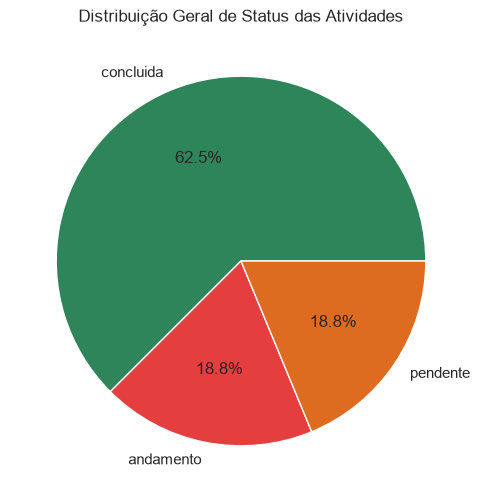

status_atual
concluida    10
andamento     3
pendente      3
Name: count, dtype: int64


In [240]:

status_andamento = mentorada['status_atual'].value_counts(normalize=True) * 100



status_andamento = mentorada['status_atual'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(status_andamento, labels=status_andamento.index, autopct='%1.1f%%', colors=['#2f855a', '#e53e3e', '#dd6b20'])
plt.title('Distribuição Geral de Status das Atividades')
plt.savefig('grafico_status.png', transparent=True)

plt.show()
print(status_andamento)

GRAFICO DINAMICO

In [244]:
# o grafico grande que é aO GRAFICO DE ANA Q MOSTRA AS ENTREGAS AO LONGO DAS SPRINGS.

#base ado nos dados gerais de todos os mentorados
concluidas_equipe = tabela[tabela['status_atual'] == 'concluida']
media_equipe = concluidas_equipe['duracao_em_dias'].mean()
teto_do_grafico = concluidas_equipe['duracao_em_dias'].max() + 2

# 2. pra cada atividade
mapa_de_cores = {
    'alta': '#E74C3C',    # Vermelho Alerta
    'Alta': '#E74C3C',
    'média': '#F39C12',   # Laranja/Amarelo Atenção
    'media': '#F39C12',
    'Média': '#F39C12',
    'baixa': '#2ECC71',   # Verde Tranquilo
    'Baixa': '#2ECC71'
}

# 3. definir grafico
def criar_grafico_evolucao(dataset_alvo, titulo_do_grafico):

    df_plot = dataset_alvo[dataset_alvo['status_atual'] == 'concluida'].copy()

#separar por sring
    df_plot['sprint_num'] = df_plot['titulo'].str.extract(r'Sprint (\d+)').astype(int)
    df_plot['nome_sprint'] = df_plot['titulo'].str.extract(r'(Sprint \d+)')
    df_plot = df_plot.sort_values('sprint_num')

    fig = px.scatter(
        df_plot,
        x='nome_sprint',
        y='duracao_em_dias',
        color='prioridade',
        color_discrete_map=mapa_de_cores,
        hover_data=['titulo', 'mentorado'],
        title=titulo_do_grafico,
        labels={'duracao_em_dias': 'Dias Gastos', 'nome_sprint': 'Sprint', 'prioridade': 'Dificuldade'}
    )

    fig.add_hline(
        y=media_equipe,
        line_dash="dash",
        line_color="gray",
        annotation_text=f"Média Geral ({media_equipe:.1f} dias)",
        annotation_position="bottom right"
    )

    # bolas do grafico
    fig.update_traces(marker=dict(size=14, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))
    fig.update_yaxes(range=[0, teto_do_grafico])

    return fig

# 3. GERANDO OS DOIS GRÁFICOS COM 1 LINHA DE CÓDIGO CADA

grafico_ana = criar_grafico_evolucao(mentorada, " Evolução Individual X Média da Equipe ")

# Exibindo as duas obras de arte

grafico_ana.show()

#oq esta acontecendo? : ele pega os dias gastos(duraçao_em_dias das atividades CONCLUIDAS) e coloca as sprint, ai podemos ver, de forma dinamica, as tarefas q foram concluidas, e as informações contidas

##Tabela

In [245]:

#usar o historico de entregas de todos os mentorados para ter um parametro de atividade dos mentorados atravez das
historico_geral = tabela[tabela['status_atual'] == 'concluida']
media_por_prioridade = historico_geral.groupby('prioridade')['duracao_em_dias'].mean().round(1)

tabela_ativas_ana = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()

# Injetamos a meta na tabela da Ana cruzando a prioridade
mentorada['meta_dias'] = mentorada['prioridade'].map(media_por_prioridade)

def sinalizar_status_real(linha): #verificação linha por linha do pandas para chegar nos resultados
    dias = linha['duracao_em_dias'] #mostra há quantos dias aquela atividade está rolando (desde que foi criada ou iniciada até a nossa data de corte).
    meta = linha['meta_dias'] #usar a coluna correta 'meta_dias'

    if linha['status_atual'] == 'pendente':
        return '🔴 Crítico (Fila)' if dias > 10 else '⚪ Pendente Normal'

    elif linha['status_atual'] == 'andamento':
        if dias > (meta * 2):
            return '🔴 Crítico'
        elif dias > meta:
            return '🟡 Atrasado'
        else:
            # Adicionado para tarefas em 'andamento' mas 'Dentro do Prazo'
            return '🟢 Dentro do Prazo'
    else:
        # Adicionado para tarefas 'concluida' que não tinham retorno
        return '✔️ Entregue'
mentorada['Diagnostico'] = mentorada.apply(sinalizar_status_real, axis=1)
mentorada['dias_de_atraso'] = mentorada['duracao_em_dias'] - mentorada['meta_dias']

atvd_ativa_ = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()
tabela_completa_ana = atvd_ativa_[[
    'titulo', 'mentorado', 'prioridade', 'status_atual',
    'duracao_em_dias', 'meta_dias', 'dias_de_atraso', 'Diagnostico'
]].sort_values(by='dias_de_atraso', ascending=False)




condicao_problema_ana = tabela_completa_ana['Diagnostico'].str.contains('🔴|🟡')
tabela_problemas_ana = tabela_completa_ana[condicao_problema_ana].drop(columns=['dias_de_atraso'])


print("=== TABELA DE visualização de atividades não entregues) ===")
display(tabela_problemas_ana)


=== TABELA DE visualização de atividades não entregues) ===


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
36,Otimizar Pipeline CI/CD - Sprint 2,Ana Ribeiro,media,pendente,21.0,11.4,🔴 Crítico (Fila)
34,Implementar Tabelas no BD - Sprint 5,Ana Ribeiro,alta,pendente,17.0,9.9,🔴 Crítico (Fila)
17,Implementar Scripts de Deploy - Sprint 1,Ana Ribeiro,alta,andamento,14.0,9.9,🟡 Atrasado


In [246]:
# 2. TABELA DE FLUXO NORMAL (Apenas 🟢 Prazo e ⚪ Fila Normal)
condicao_saudavel_ana = tabela_completa_ana['Diagnostico'].str.contains('🟢|⚪')
tabela_saudaveis_ana = tabela_completa_ana[condicao_saudavel_ana].drop(columns=['dias_de_atraso'])


display(tabela_saudaveis_ana)


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
66,Atualizar Scripts de Deploy - Sprint 9,Ana Ribeiro,alta,andamento,5.0,9.9,🟢 Dentro do Prazo
56,Otimizar Scripts de Deploy - Sprint 8,Ana Ribeiro,alta,pendente,4.0,9.9,⚪ Pendente Normal
49,Criar Pipeline CI/CD - Sprint 7,Ana Ribeiro,alta,andamento,2.0,9.9,🟢 Dentro do Prazo


TABELA PARA VISUALIZAR OS SALDOS DE TODOS OS MENTORADOS E SUAS ATIVIDADES Q ESTAO FORA DA

In [247]:

#tabela geral
historico_geral = tabela[tabela['status_atual'] == 'concluida']
media_por_prioridade = historico_geral.groupby('prioridade')['duracao_em_dias'].mean().round(1)

tabela_ativas_ana = tabela[tabela['status_atual'].isin(['andamento', 'pendente'])].copy()

# Injetamos a meta na tabela tabela cruzando a prioridade
tabela['meta_dias'] = tabela['prioridade'].map(media_por_prioridade)

def sinalizar_status_real(linha):
    dias = linha['duracao_em_dias']
    meta = linha['meta_dias']

    if linha['status_atual'] == 'pendente':
        return '🔴 Crítico (Fila)' if dias > 10 else '⚪ Pendente Normal'

    elif linha['status_atual'] == 'andamento':
        if dias > (meta * 2):
            return '🔴 Crítico'
        elif dias > meta:
            return '🟡 Atrasado'
        else:
            # Adicionado para tarefas em 'andamento' mas 'Dentro do Prazo'
            return '🟢 Dentro do Prazo'
    else:
        # Adicionado para tarefas 'concluida' que não tinham retorno
        return '✔️ Entregue'

tabela['Diagnostico'] = tabela.apply(sinalizar_status_real, axis=1)
tabela['dias_de_atraso'] = tabela['duracao_em_dias'] - tabela['meta_dias']

# Pegamos apenas quem NÃO está concluído
tabela_ativas = tabela[tabela['status_atual'].isin(['andamento', 'pendente'])].copy()


tabela_completa = tabela_ativas[[
    'titulo', 'mentorado', 'prioridade', 'status_atual',
    'duracao_em_dias', 'meta_dias', 'dias_de_atraso', 'Diagnostico'
]].sort_values(by='dias_de_atraso', ascending=False)


#fazer o filtro para não mostrar nada que esteja ok, entregue ou no prazo
condicao_problema = tabela_completa['Diagnostico'].str.contains('🔴|🟡')
tabela_problemas = tabela_completa[condicao_problema].drop(columns=['dias_de_atraso'])


print("=== TABELA DE verificação de tividades não entregues")
display(tabela_problemas)


=== TABELA DE verificação de tividades não entregues


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
46,Testar Fluxo de Autenticação - Sprint 3,Felipe Andrade,alta,andamento,24.0,9.9,🔴 Crítico
5,Documentar Acessibilidade (WCAG) - Sprint 7,Henrique Alves,baixa,andamento,24.0,10.2,🔴 Crítico
45,Testar Scripts de Deploy - Sprint 2,Diego Martins,alta,andamento,23.0,9.9,🔴 Crítico
0,Otimizar Microsserviços - Sprint 8,Bruno Costa,media,andamento,24.0,11.4,🔴 Crítico
8,Atualizar Acessibilidade (WCAG) - Sprint 1,Henrique Alves,media,andamento,24.0,11.4,🔴 Crítico
57,Implementar Fluxo de Autenticação - Sprint 10,Gabriela Pinto,alta,andamento,22.0,9.9,🔴 Crítico
38,Testar Componentes React - Sprint 9,Diego Martins,media,andamento,23.0,11.4,🔴 Crítico
23,Testar Scripts de Deploy - Sprint 2,Felipe Andrade,alta,andamento,20.0,9.9,🔴 Crítico
47,Analisar Pipeline CI/CD - Sprint 2,Felipe Andrade,baixa,pendente,20.0,10.2,🔴 Crítico (Fila)
36,Otimizar Pipeline CI/CD - Sprint 2,Ana Ribeiro,media,pendente,21.0,11.4,🔴 Crítico (Fila)


In [248]:
# 2. TABELA DE FLUXO NORMAL (Apenas 🟢 Prazo e ⚪ Fila Normal)
condicao_saudavel = tabela_completa['Diagnostico'].str.contains('🟢|⚪')
tabela_saudaveis = tabela_completa[condicao_saudavel].drop(columns=['dias_de_atraso'])

print("\n=== ✅ FLUXO NORMAL (TUDO SOB CONTROLE) ===")
display(tabela_saudaveis)


=== ✅ FLUXO NORMAL (TUDO SOB CONTROLE) ===


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
63,Atualizar Exportação de Relatórios - Sprint 1,Camila Lopes,media,andamento,9.0,11.4,🟢 Dentro do Prazo
53,Implementar Fluxo de Autenticação - Sprint 1,Gabriela Pinto,alta,andamento,6.0,9.9,🟢 Dentro do Prazo
26,Criar API de Login - Sprint 2,Bruno Costa,alta,pendente,5.0,9.9,⚪ Pendente Normal
66,Atualizar Scripts de Deploy - Sprint 9,Ana Ribeiro,alta,andamento,5.0,9.9,🟢 Dentro do Prazo
55,Analisar Microsserviços - Sprint 6,Diego Martins,baixa,pendente,5.0,10.2,⚪ Pendente Normal
15,Documentar Exportação de Relatórios - Sprint 9,Camila Lopes,baixa,pendente,5.0,10.2,⚪ Pendente Normal
27,Implementar Filtros de Busca - Sprint 3,Gabriela Pinto,alta,pendente,4.0,9.9,⚪ Pendente Normal
56,Otimizar Scripts de Deploy - Sprint 8,Ana Ribeiro,alta,pendente,4.0,9.9,⚪ Pendente Normal
42,Testar Pipeline CI/CD - Sprint 4,Diego Martins,media,pendente,4.0,11.4,⚪ Pendente Normal
49,Criar Pipeline CI/CD - Sprint 7,Ana Ribeiro,alta,andamento,2.0,9.9,🟢 Dentro do Prazo
